## Import Librerie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

## Caricamento dataset

Separazione Feature/Target

Trasformazione target con logaritmo per:
- ridurre la variabilità dei prezzi
- rendere il problema di regressione più stabile
- aiutare la rete a imparare meglio.

In [2]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
y = np.log1p(y)

## Divisione dataset in train/test

Train --> Allenare

Test --> Valutare

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Normalizzazione delle feature

Portiamo tutte le variabili sulla stessa scala

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Definizione architettura rete neurale

La rete è composta da:
- input layer (dimensione delle feature)
- hidden layers (64 → 32 → 16 neuroni)
- output layer (1 neurone)

Tecniche per migliorare l'apprendimento:
- Batch Normalization → stabilizza il training
- Dropout → riduce l’overfitting.

In [5]:
'''model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))


model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(1))'''


model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

C:\Users\veryv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Configurazione apprendimento del modello

In [6]:
opt = Adam(learning_rate=0.0005)

model.compile(
    optimizer=opt,
    loss='huber',
    metrics=['mae']
)

## Struttura della rete

Serve per visualizzare l’architettura del modello:
- numero di layer
- numero di neuroni
- numero totale di parametri da apprendere.

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 192 (768.00 B)

## Definizione strategie di controllo del training
Servono per:
- fermare l’allenamento quando il modello non migliora più
- ridurre il learning rate quando l’apprendimento rallenta

Questi strumenti aiutano a:
- evitare overfitting
- migliorare la convergenza
- rendere il training più efficiente

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

## Training rete neurale

Apprendimento vero e proprio della rete neurale

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.1059 - mae: 0.3513 - val_loss: 0.0308 - val_mae: 0.1894 - learning_rate: 5.0000e-04
Epoch 2/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0441 - mae: 0.2301 - val_loss: 0.0255 - val_mae: 0.1736 - learning_rate: 5.0000e-04
Epoch 3/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0338 - mae: 0.2024 - val_loss: 0.0234 - val_mae: 0.1670 - learning_rate: 5.0000e-04
Epoch 4/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0294 - mae: 0.1878 - val_loss: 0.0225 - val_mae: 0.1628 - learning_rate: 5.0000e-04
Epoch 5/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0270 - mae: 0.1794 - val_loss: 0.0213 - val_mae: 0.1563 - learning_rate: 5.0000e-04
Epoch 6/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0248 - mae: 0.1712 - val_loss: 0.0205 - val_mae: 0.1526 - learning_rate: 5.0000e-04
Epoch 7/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0236 - mae: 0.1671 - val_loss: 0.0199 - val_mae: 0.1536

## Visualizzazione andamento del training

Visualizzazione di come il modello ha imparato nel tempo.

I grafici mostrano:
- errore sul training
- errore sulla validazione

Servono per capire se:
- il modello sta migliorando
- sta facendo overfitting
- il training è stabile

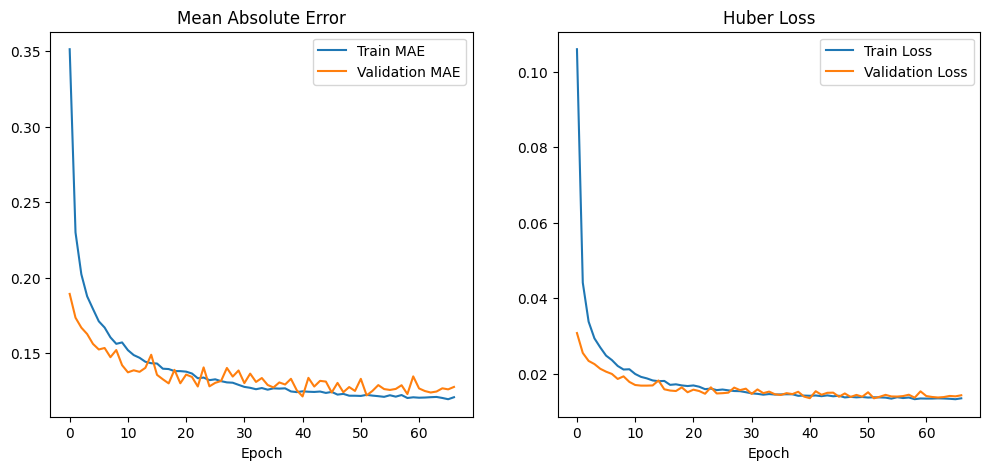

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title("Mean Absolute Error")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Huber Loss")
plt.xlabel("Epoch")
plt.legend()

plt.show()

## Valutazione finale del modello

Qui misuri le prestazioni del modello su dati mai visti prima.

Questo ti dà una stima reale di:
- quanto il modello sbaglia nelle previsioni
- quanto bene generalizza

In [11]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0132 - mae: 0.1201
Test Loss: 0.013180375099182129
Test MAE: 0.12006188184022903
